# Simple End-to-End Example

Ici on présente un exemple simple et complet avec une collection de traces simulées à partir d'un réseau.
Le réseau est un extrait de la BDTOPO située sur un versant de montagne en face de la ville de Chamonix.
Les données du réseau sont téléchargées par flux WFS.

In [1]:
import os
import sys

import matplotlib.pyplot as plt

# Import de tracklib
module_path = os.path.abspath(os.path.join('../../../../tracklib'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Import de OFNP
module_path = os.path.abspath(os.path.join('../../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import tracklib as tkl

  0% (0 of 80) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--

PAGE 1/1


100% (80 of 80) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
 16% (13 of 80) |###                     | Elapsed Time: 0:00:00 ETA:   0:00:00

Building [4411 x 4202] spatial index...


100% (80 of 80) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00


Number of edges= 80
Number of nodes= 70


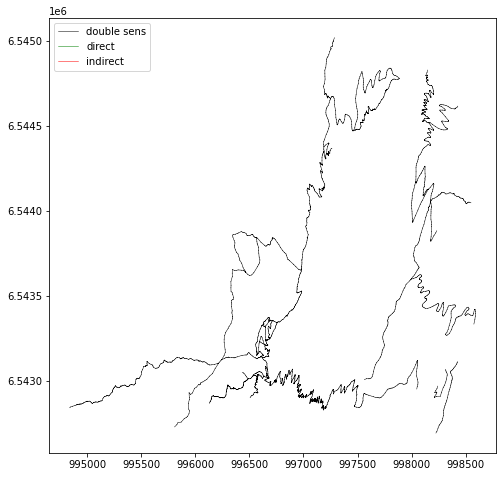

In [2]:
xmin = 6.8165550
xmax = 6.8496992
ymin = 45.92171
ymax = 45.93695

bbox = tkl.Bbox(tkl.GeoCoords(xmin, ymin), tkl.GeoCoords(xmax, ymax))
tolerance = 0.0001

spatialIndex = True

network = tkl.NetworkReader.requestFromIgnGeoportail(bbox, tolerance=tolerance, spatialIndex=spatialIndex)
network.toENUCoords(2154)

plt.figure(figsize=(8, 8))
network.plot('k-', '', 'g-', 'r-', 0.5, plt)
print ('Number of edges=', len(network.EDGES))
print ('Number of nodes=', len(network.NODES))
plt.legend()

100% (200 of 200) |######################| Elapsed Time: 0:00:14 Time:  0:00:140001


------------------------------------------------------------
115 (57.5 %) tracks generated on network
------------------------------------------------------------


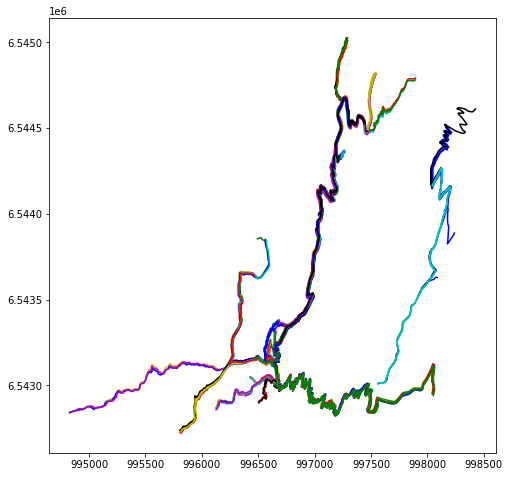

In [3]:
#
noiser = tkl.NoiseProcess(amps=5, kernels=tkl.ExponentialKernel(500))

# generate simulated trajectories from the network 
collection = tkl.generateTracksOnNetwork(network, N=200, p_round_trip=0.05, p_cplx_trip=0.10, resolution=1, noiser=noiser)

# add 3 attributes
for idx, track in enumerate(collection):
    track.createAnalyticalFeature('num', idx+1)
    track.createAnalyticalFeature('user_id', idx+1)
    track.createAnalyticalFeature('track_id', idx+1)

#
plt.figure(figsize=(8, 8))
collection.plot(append=plt)

## Dossier de stockage des résultats

In [4]:
from ofnp import setupenv

RESPATH = r'/home/md_vandamme/4_RESEAU/ZTEMP/'

setupenv(RESPATH)


## Step 1 : segment and resample

In [5]:
from ofnp import segmentation_resample

# Paramètre : Nombre de points minimum pour un morceau de trace au moment du découpage
#             si le nombre n'est pas atteint, le morceau de trace est oublié
NB_OBS_MIN           = 10

# Paramètre : Distance en mètres entre 2 points, si supérieure au seuil on coupe la trace
DIST_MAX_2OBS        = 50


RESAMPLE_SIZE_GRID = 1
RESAMPLE_SIZE_FUSION = 5

# =============================================================================
#  On définit un format pour le stockage des traces modifiées dans le pipeline
fmt = tkl.TrackFormat({'ext': 'CSV',
                           'srid': 'ENU',
                           'id_E': 1, 'id_N': 0, 'id_U': 3, 'id_T': 2,
                           'time_fmt': '2D/2M/4Y 2h:2m:2s',
                           'separator': ';',
                           'header': 0,
                           'cmt': '#',
                           'read_all': True})
segmentation_resample(RESPATH, collection, fmt, NB_OBS_MIN, DIST_MAX_2OBS,
                    RESAMPLE_SIZE_GRID, RESAMPLE_SIZE_FUSION)



Starting segmentation and resampling...
Starting segmentation ...
     Number of tracks after segmentation: 115
Finished saving segmented tracks.
Starting resampling ...
Number files to load:  115
    Number of tracks after resampling: 115
    Number of tracks after resampling: 115
Finished saving resampled tracks.
Stage 1 finished: segmentation and resampling.


## Step 2 : calculs des cartes de densités, de constraste et binaire

In [6]:
from ofnp import density_polygonize

RESAMPLE_SIZE_GRID = 1

G1_SIZE = 2
G2_SIZE = 30 # 50

SEUIL_DENSITE = 360  # 15 - 1000
SEUIL_SURFACE = 1000 # m2 - 50000 - 7000

f = 2   # Cut factor

# =============================================================================
#
density_polygonize(RESPATH, G1_SIZE, G2_SIZE, SEUIL_DENSITE, SEUIL_SURFACE,
                       prefix='PT', rep='resample_grid', f=2)



----------------------------------------------------------------------
STAGE 2 :                                   
   - Calcul d’une carte de densité à partir des traces GNSS 
   - De la vectorisation on extrait une ligne centrée ≡ arc de la topologie 
----------------------------------------------------------------------
Number files to load:  115
<class 'tracklib.core.track.Track'>


TypeError: cannot unpack non-iterable NoneType object